In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mutations = ['A>C', 'A>G', 'A>T', 'C>A', 'C>G', 'C>T', 'G>A', 'G>C', 'G>T', 'T>A', 'T>C', 'T>G']


In [3]:
species = pd.read_csv('./data/species.csv')
species['taxid'] = species['taxid'].astype(str)
species.head()

,taxid,species,genus,family,order,class,phylum,kingdom,superkingdom,Nucleotide_Count,Type
0,38170,Avian orthoreovirus__38170,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,4363,ds
1,1157337,Piscine orthoreovirus__1157337,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,2478,ds
2,351073,Mammalian orthoreovirus__351073,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,2366,ds
3,40054,Epizootic hemorrhagic disease virus__40054,Orbivirus__10892,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,1773,ds
4,10990,Rice black streaked dwarf virus__10990,Fijivirus__10988,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,1149,ds


In [4]:
df = pd.read_csv('./data/viral_spectra_dataset.csv')\
    .merge(species[['taxid', 'family']], how='left')
df

,A>C,A>G,A>T,C>A,C>G,C>T,G>A,G>C,G>T,T>A,T>C,T>G,Type,taxname,df,taxid,virusname,family
0,0.109127,0.117342,0.073464,0.060217,0.011690,0.149450,0.196651,0.026968,0.020779,0.036932,0.132424,0.064957,ds,Hepatitis B virus,nemu,10407,HBV,NaN
1,0.034784,0.086621,0.027108,0.044784,0.006846,0.339187,0.234664,0.000000,0.102792,0.009995,0.095861,0.017356,ds,Rice black streaked dwarf virus,nemu,10990,RBSDV,Reoviridae__10880
2,0.012922,0.127692,0.009847,0.022595,0.001792,0.379747,0.123494,0.003866,0.031890,0.022814,0.249177,0.014165,+,West Nile virus,nemu,11082,WNV,Flaviviridae__11050
3,0.008852,0.143715,0.014274,0.079285,0.000000,0.198377,0.334457,0.000000,0.058034,0.031512,0.126587,0.004907,-,Influenza A virus,nemu,11320,flu_a,Orthomyxoviridae__11308
4,0.009244,0.183506,0.025201,0.014157,0.002805,0.243095,0.227613,0.012168,0.021287,0.031341,0.224274,0.005309,+,Norwalk virus,nemu,11983,norw,Caliciviridae__11974
5,0.008840,0.102109,0.025178,0.031668,0.010016,0.490211,0.153864,0.018815,0.025828,0.020681,0.106414,0.006376,+,Hepatovirus A,nemu,12092,HAV,NaN
6,0.012652,0.223645,0.018232,0.014670,0.002589,0.201530,0.137092,0.014227,0.017123,0.020364,0.319673,0.018203,+,Foot-and-mouth disease virus,nemu,12110,FMDV,Picornaviridae__12058
7,0.023573,0.236911,0.063843,0.026172,0.019579,0.233199,0.139336,0.012520,0.030695,0.032620,0.165367,0.016185,+,Citrus tristeza virus,nemu,12162,CTV,Closteroviridae__69973
8,0.007133,0.108281,0.018650,0.025002,0.004258,0.287104,0.184085,0.007617,0.012060,0.041765,0.293600,0.010445,+,Dengue virus,nemu,12637,denv,Flaviviridae__11050
9,0.017020,0.091356,0.028301,0.044811,0.004483,0.357214,0.095441,0.009720,0.158906,0.017986,0.153859,0.020902,+,Porcine epidemic diarrhea virus,nemu,28295,PEDV,Coronaviridae__11118


<Axes: xlabel='Type-virusname', ylabel='Type-virusname'>

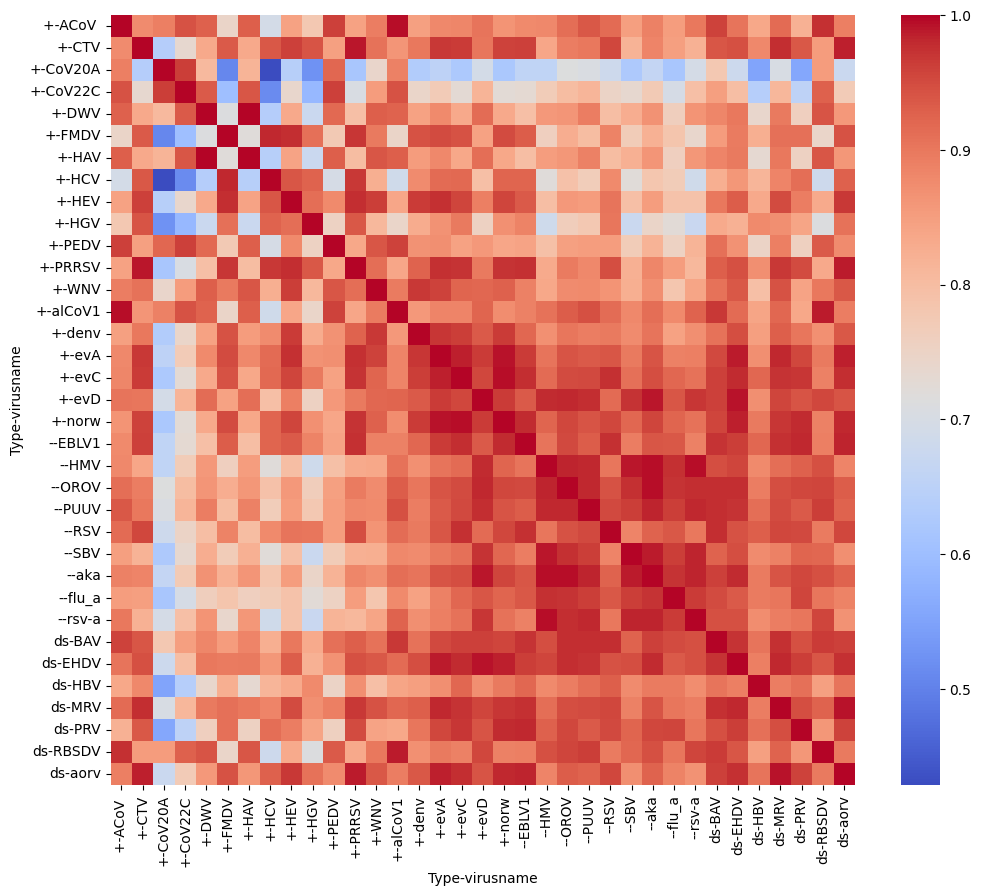

In [5]:
from scipy.spatial.distance import pdist, squareform
_s = df.set_index(['Type', 'virusname'])[mutations].sort_index()
cossim = 1 - squareform(pdist(_s, metric='cosine'))
cossim = pd.DataFrame(cossim, index=_s.index, columns=_s.index)

plt.figure(figsize=(12, 10))
sns.heatmap(cossim, cmap='coolwarm')

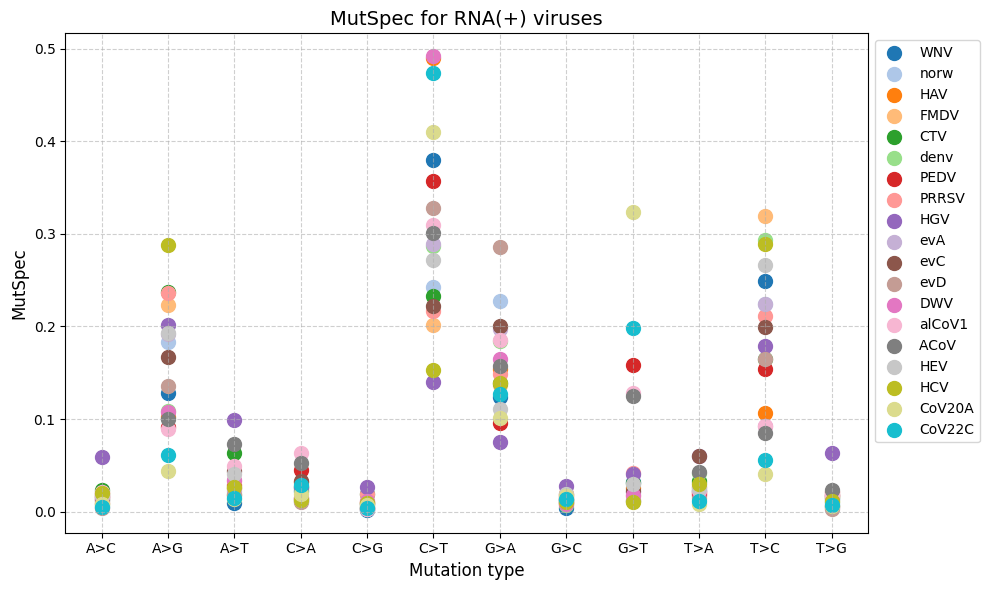

In [6]:
cmap = plt.get_cmap('tab20')
colors = [cmap(i) for i in range(len(df[df['Type'] == '+']))]

# create plot
plt.figure(figsize=(10, 6))

# add dots for each virus 
for i, row in df[df['Type'] == '+'].reset_index(drop=True).iterrows():
    plt.scatter(mutations, row[mutations], label=row['virusname'], s=100, color=colors[i])
    # print(i)

# plot settings 
plt.xlabel('Mutation type', fontsize=12)
plt.ylabel('MutSpec', fontsize=12)
plt.title('MutSpec for RNA(+) viruses', fontsize=14)
# plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

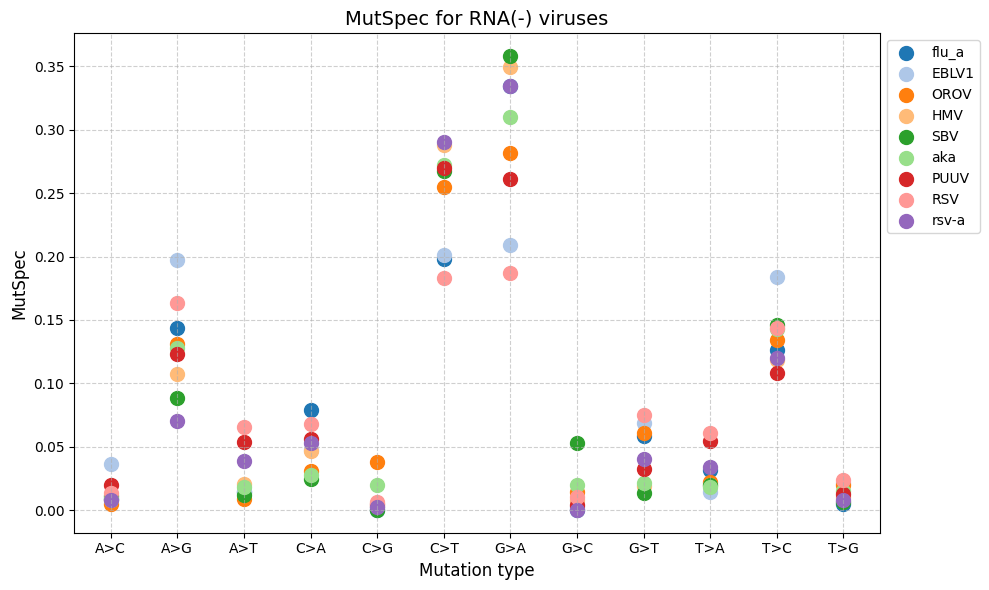

In [7]:
# create plot
plt.figure(figsize=(10, 6))

# add dots for each virus 
for i, row in df[df['Type'] == '-'].reset_index(drop=True).iterrows():
    plt.scatter(mutations, row[mutations], label=row['virusname'], s=100, color=colors[i])

# plot settings 
plt.xlabel('Mutation type', fontsize=12)
plt.ylabel('MutSpec', fontsize=12)
plt.title('MutSpec for RNA(-) viruses', fontsize=14)
# plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

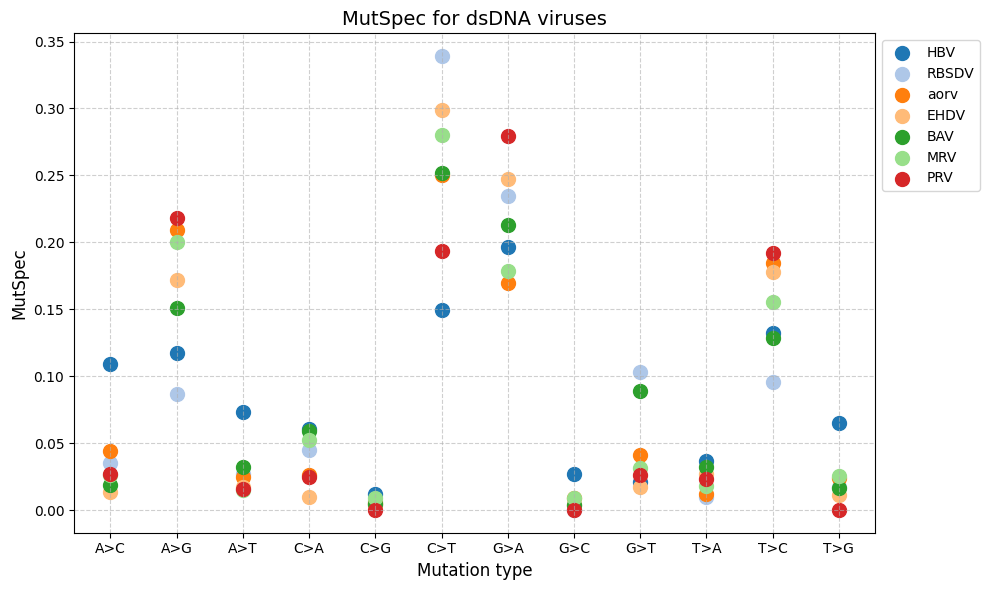

In [8]:
# create plot
plt.figure(figsize=(10, 6))

# add dots for each virus 
for i, row in df[df['Type'] == 'ds'].reset_index(drop=True).iterrows():
    plt.scatter(mutations, row[mutations], label=row['virusname'], s=100, color=colors[i])

# plot settings 
plt.xlabel('Mutation type', fontsize=12)
plt.ylabel('MutSpec', fontsize=12)
plt.title('MutSpec for dsDNA viruses', fontsize=14)
# plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# color_mapping12 = {
#     "C>A": "deepskyblue",
#     "G>T": "deepskyblue",
#     "C>G": "black",
#     "G>C": "black",
#     "C>T": "red",
#     "G>A": "red",
#     "T>A": "silver",
#     "A>T": "silver",
#     "T>C": "yellowgreen",
#     "A>G": "yellowgreen",
#     "T>G": "pink",
#     "A>C": "pink",
# }

In [5]:
# list of mutations
mutations = ['A>C', 'A>G', 'A>T', 'C>A', 'C>G', 'C>T', 'G>A', 'G>C', 'G>T', 'T>A', 'T>C', 'T>G']

In [6]:
cov_like = df[(df.virusname.str.startswith('CoV')) | (df.family == 'Coronaviridae__11118')].virusname.values
cov_like

<StringArray>
['PEDV', 'alCoV1', 'ACoV ', 'CoV20A', 'CoV22C']
Length: 5, dtype: str

In [7]:
df_long = df.melt(id_vars=['Type', 'taxname', 'virusname'], value_vars=mutations, 
                  var_name='Mutation', value_name='MutSpec')
df_long['group'] = df_long['Type']
df_long.loc[df_long['virusname'].isin(cov_like), 'group'] = '+ssRNA (4 CoV)'

df_long.loc[df_long['group']=='-', 'group'] = '-ssRNA (11)'
df_long.loc[df_long['group']=='+', 'group'] = '+ssRNA (14)'
df_long.loc[df_long['group']=='ds', 'group'] = 'dsDNA (7)'

df_long

,Type,taxname,virusname,Mutation,MutSpec,group
0,ds,Hepatitis B virus,HBV,A>C,0.109127,dsDNA (7)
1,ds,Rice black streaked dwarf virus,RBSDV,A>C,0.034784,dsDNA (7)
2,+,West Nile virus,WNV,A>C,0.012922,+ssRNA (14)
3,-,Influenza A virus,flu_a,A>C,0.008852,-ssRNA (11)
4,+,Norwalk virus,norw,A>C,0.009244,+ssRNA (14)
...,...,...,...,...,...,...
415,-,Puumala orthohantavirus,PUUV,T>G,0.012302,-ssRNA (11)
416,-,Rice stripe tenuivirus,RSV,T>G,0.023569,-ssRNA (11)
417,-,RSV-A,rsv-a,T>G,0.008174,-ssRNA (11)
418,+,SARS-CoV-2 20A,CoV20A,T>G,0.006130,+ssRNA (4 CoV)


In [8]:
df_long.query('virusname == "flu_h1n1pdm"').MutSpec

Series([], Name: MutSpec, dtype: float64)

In [9]:
from scipy.spatial.distance import cosine
a = df_long.query('virusname == "flu_vic"').MutSpec
b = df_long.query('virusname == "flu_h1n1pdm"').MutSpec
1-cosine(a, b)

/home/kpotoh/miniforge3/envs/amino-acid-shift/lib/python3.13/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


np.float64(nan)

In [10]:
df_long[['Type', 'taxname', 'virusname', 'group']].drop_duplicates().sort_values('group')

,Type,taxname,virusname,group
17,+,Enterovirus A,evA,+ssRNA (14)
19,+,Enterovirus D,evD,+ssRNA (14)
13,+,GB virus C,HGV,+ssRNA (14)
21,+,Deformed wing virus,DWV,+ssRNA (14)
10,+,Porcine reproductive and respiratory syndrome ...,PRRSV,+ssRNA (14)
18,+,Enterovirus C,evC,+ssRNA (14)
7,+,Citrus tristeza virus,CTV,+ssRNA (14)
8,+,Dengue virus,denv,+ssRNA (14)
5,+,Hepatovirus A,HAV,+ssRNA (14)
4,+,Norwalk virus,norw,+ssRNA (14)


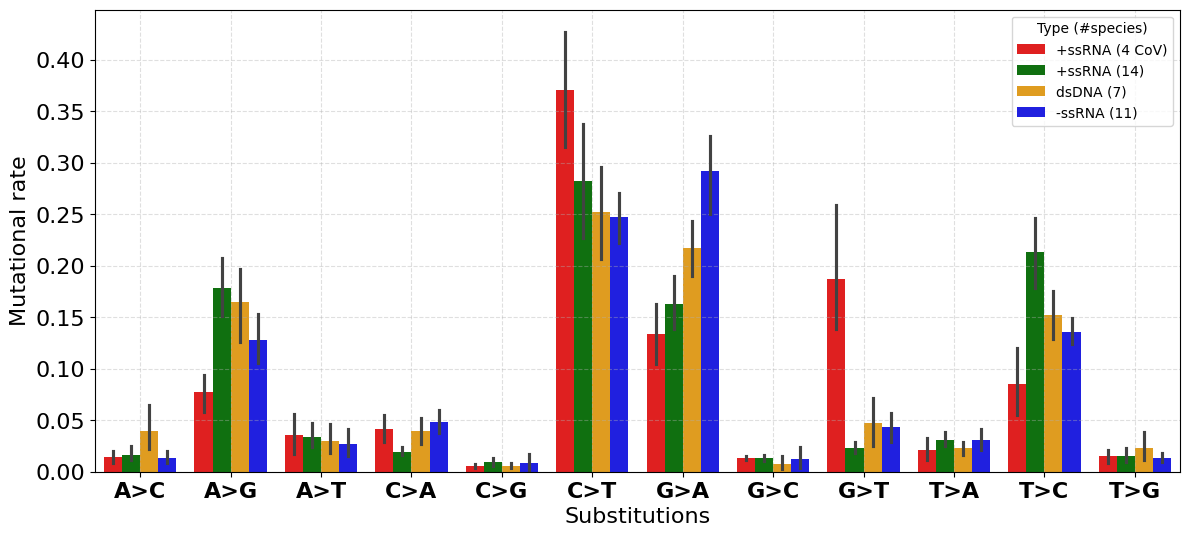

In [16]:
plt.figure(figsize=(14, 6))

sns.set_palette(sns.color_palette(['red', 'green', 'orange','blue']))

sns.barplot(
    data=df_long, x='Mutation', y='MutSpec', hue='group', 
    hue_order=['+ssRNA (4 CoV)', '+ssRNA (14)', 'dsDNA (7)', '-ssRNA (11)'])
plt.legend(title='Type (#species)')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)
plt.xlabel('Substitutions', fontsize=16)
plt.ylabel('Mutational rate', fontsize=16)
plt.grid(linestyle='--', alpha=0.4)

plt.savefig('../viral_spectra/figures/ms12grouped_all_viruses.pdf')

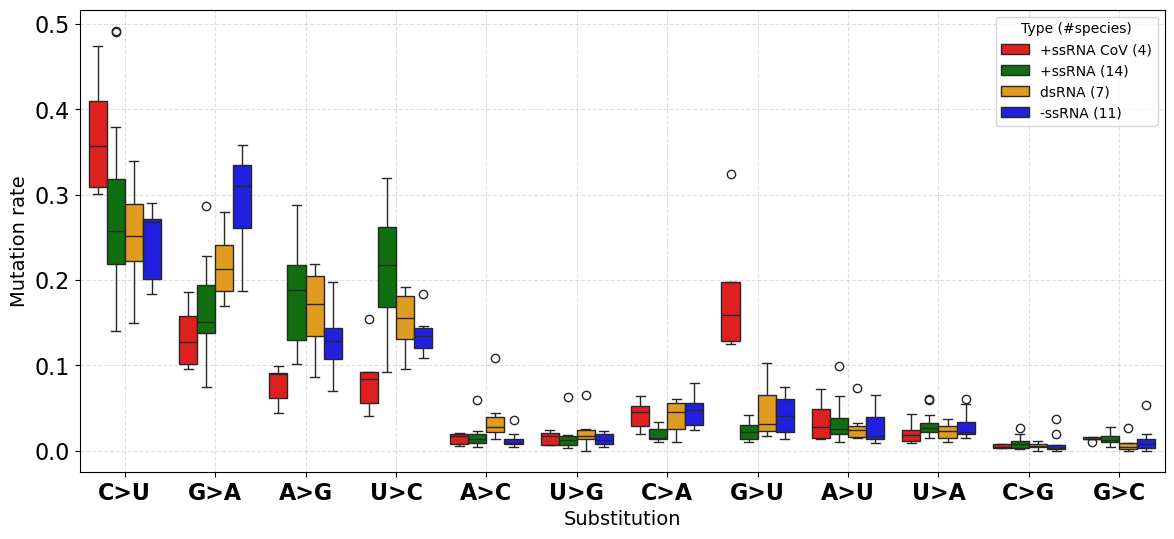

In [10]:
plt.figure(figsize=(14, 6))

sns.set_palette(sns.color_palette(['red', 'green', 'orange','blue']))

_ = df_long.copy()
_['group'] = _['group'].map({
    '+ssRNA (4 CoV)': '+ssRNA CoV (4)',
    '+ssRNA (14)': '+ssRNA (14)',
    'dsDNA (7)': 'dsRNA (7)',
    '-ssRNA (11)': '-ssRNA (11)'
})
_['Mutation'] = _['Mutation'].apply(lambda x: x.replace('T', 'U'))
sns.boxplot(
    data=_, x='Mutation', y='MutSpec', hue='group', 
    hue_order=['+ssRNA CoV (4)', '+ssRNA (14)', 'dsRNA (7)', '-ssRNA (11)'],
    order=['C>U', 'G>A', 'A>G', 'U>C', 'A>C', 'U>G', 'C>A', 'G>U', 'A>U', 'U>A', 'C>G', 'G>C'],

)
plt.legend(title='Type (#species)')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)
plt.xlabel('Substitution', fontsize=14)
plt.ylabel('Mutation rate', fontsize=14)
plt.grid(linestyle='--', alpha=0.4)

# plt.savefig('../viral_spectra/figures/ms12grouped_all_viruses.pdf')

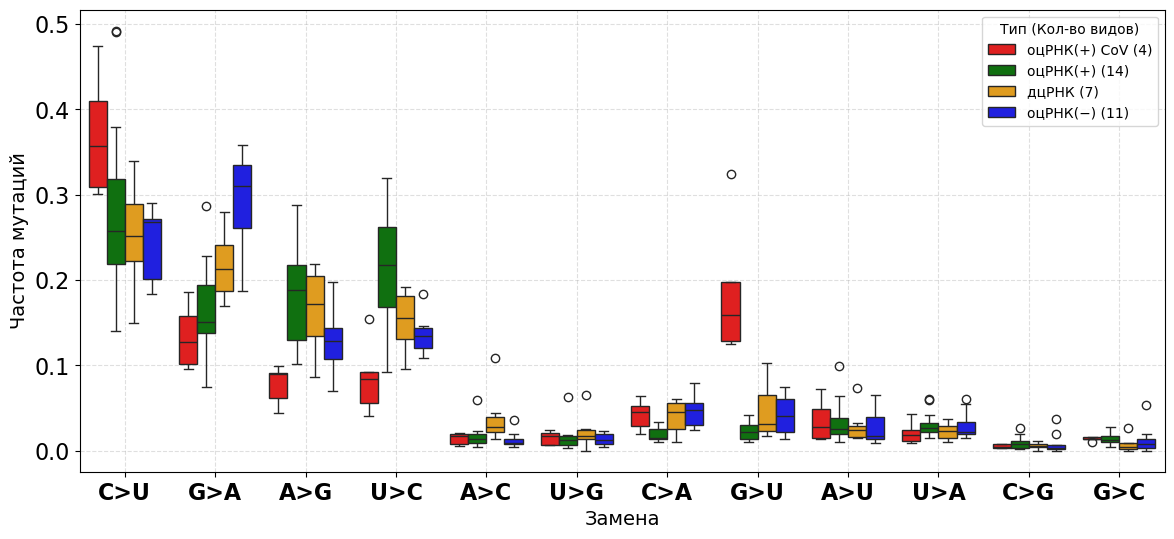

In [11]:
plt.figure(figsize=(14, 6))

sns.set_palette(sns.color_palette(['red', 'green', 'orange','blue']))

_ = df_long.copy()
_['group'] = _['group'].map({
    '+ssRNA (4 CoV)': 'оцРНК(+) CoV (4)',
    '+ssRNA (14)': 'оцРНК(+) (14)',
    'dsDNA (7)': 'дцРНК (7)',
    '-ssRNA (11)': 'оцРНК(−) (11)'
})
_['Mutation'] = _['Mutation'].apply(lambda x: x.replace('T', 'U'))

sns.boxplot(
    data=_, x='Mutation', y='MutSpec', hue='group', 
    hue_order=['оцРНК(+) CoV (4)', 'оцРНК(+) (14)', 'дцРНК (7)', 'оцРНК(−) (11)'],
    order=['C>U', 'G>A', 'A>G', 'U>C', 'A>C', 'U>G', 'C>A', 'G>U', 'A>U', 'U>A', 'C>G', 'G>C'],

)
plt.legend(title='Тип (Кол-во видов)')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)
plt.xlabel('Замена', fontsize=14)
plt.ylabel('Частота мутаций', fontsize=14)
plt.grid(linestyle='--', alpha=0.4)

# plt.savefig('../viral_spectra/figures/ms12grouped_all_viruses.pdf')

In [14]:
df_long

,Type,taxname,virusname,Mutation,MutSpec,group
0,ds,Hepatitis B virus,HBV,A>C,0.109127,dsDNA (7)
1,ds,Rice black streaked dwarf virus,RBSDV,A>C,0.034784,dsDNA (7)
2,+,West Nile virus,WNV,A>C,0.012922,+ssRNA (14)
3,-,Influenza A virus,flu_a,A>C,0.008852,-ssRNA (11)
4,+,Norwalk virus,norw,A>C,0.009244,+ssRNA (14)
...,...,...,...,...,...,...
415,-,Puumala orthohantavirus,PUUV,T>G,0.012302,-ssRNA (11)
416,-,Rice stripe tenuivirus,RSV,T>G,0.023569,-ssRNA (11)
417,-,RSV-A,rsv-a,T>G,0.008174,-ssRNA (11)
418,+,SARS-CoV-2 20A,CoV20A,T>G,0.006130,+ssRNA (4 CoV)


In [19]:
import pingouin as pg

for mut in ['C>T', 'G>A', 'A>G', 'T>C']:
    print(f'Analyzing {mut}...')
    cur_df = df_long.query(f'Mutation == "{mut}"')
    if pg.normality(cur_df, dv='MutSpec', group='group').normal.all():
        parametric = True
    else:
        print(f'{mut} is not normal, using non-parametric test')
        parametric = False

    _ = pg.pairwise_tests(data=cur_df,
        dv='MutSpec', between='group', padjust='bonf', parametric=parametric)
    _res = _[['A', 'B', 'p-corr']][(_['p-corr'] < 0.05) & (~_['A'].str.contains('CoV')) & (~_['B'].str.contains('CoV'))]
    if len(_res) > 0:
        print(f'Significant differences for {mut}:')
        print(_res)
    print('---\n')

Analyzing C>T...
---

Analyzing G>A...
Significant differences for G>A:
             A            B    p-corr
1  +ssRNA (14)  -ssRNA (11)  0.000697
---

Analyzing A>G...
---

Analyzing T>C...
Significant differences for T>C:
             A            B    p-corr
1  +ssRNA (14)  -ssRNA (11)  0.006321
---



/tmp/ipykernel_39194/1214231935.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['C>U', 'G>A', 'A>G', 'U>C'], fontsize=16, fontweight='bold')


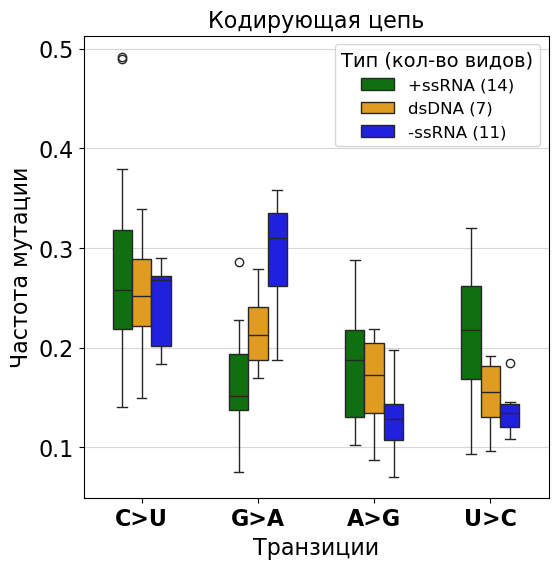

In [16]:
plt.figure(figsize=(6, 6))

sns.set_palette(sns.color_palette(['green', 'orange','blue']))

ax = sns.boxplot(
    data=df_long, x='Mutation', y='MutSpec', hue='group', 
    hue_order=[ '+ssRNA (14)', 'dsDNA (7)', '-ssRNA (11)'],
    order=['C>T', 'G>A', 'A>G', 'T>C'],
    width=0.5,
)
plt.title('Кодирующая цепь', fontsize=16)
plt.legend(title='Тип (кол-во видов)', fontsize=12, title_fontsize=14)
plt.yticks(fontsize=16)
plt.xlabel('Транзиции', fontsize=16)
plt.ylabel('Частота мутации', fontsize=16)
ax.set_xticklabels(['C>U', 'G>A', 'A>G', 'U>C'], fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.5)
ax.set_axisbelow(True)

In [9]:
df_long['group'].value_counts() / 12

group
+ssRNA (14)       14.0
-ssRNA (11)       11.0
dsDNA (7)          7.0
+ssRNA (4 CoV)     5.0
Name: count, dtype: float64

In [10]:
(df_long['group'].value_counts() / 12).sum()

np.float64(37.0)

In [8]:
nonseg = ['European bat 1 lyssavirus', 'Human metapneumovirus', 'RSV-A', 'RSV-B']

df_long_neg = df_long.query('group == "-ssRNA (11)"').copy()
df_long_neg['group'] = 'segmented'
df_long_neg.loc[df_long_neg['taxname'].isin(nonseg), 'group'] = 'non-segmented'
df_long_neg.group.value_counts()/12

group
segmented        6.0
non-segmented    3.0
Name: count, dtype: float64

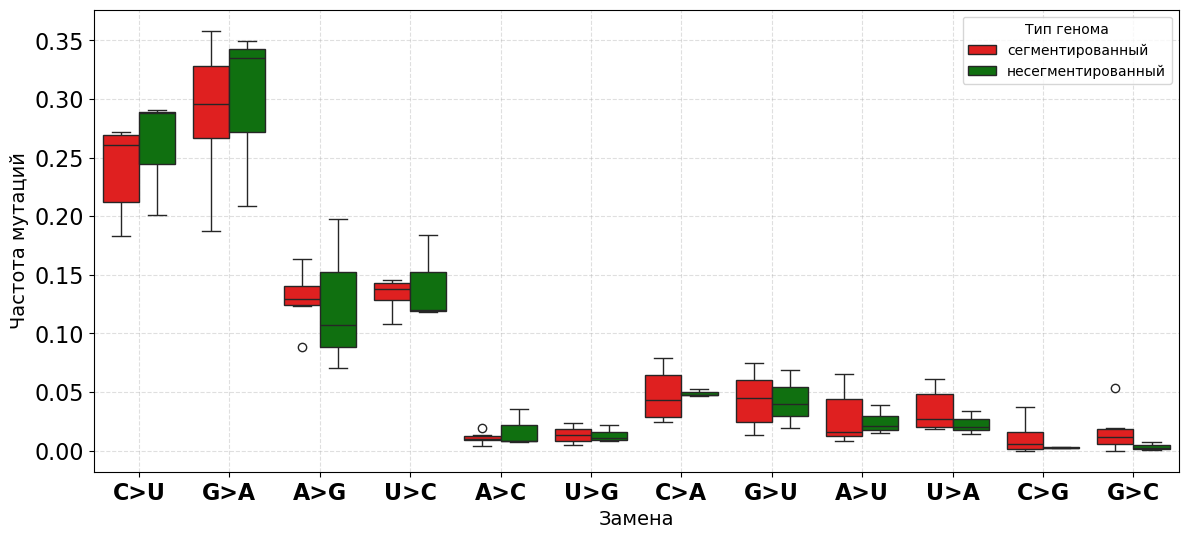

In [10]:
plt.figure(figsize=(14, 6))

sns.set_palette(sns.color_palette(['red', 'green', 'orange','blue']))

_ = df_long_neg.copy()
_['group'] = _['group'].map({
    'segmented': 'сегментированный',
    'non-segmented': 'несегментированный',
})
_['Mutation'] = _['Mutation'].apply(lambda x: x.replace('T', 'U'))

sns.boxplot(
    data=_, x='Mutation', y='MutSpec', hue='group', 
    hue_order=['сегментированный', 'несегментированный'],
    order=['C>U', 'G>A', 'A>G', 'U>C', 'A>C', 'U>G', 'C>A', 'G>U', 'A>U', 'U>A', 'C>G', 'G>C'],

)
plt.legend(title='Тип генома')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)
plt.xlabel('Замена', fontsize=14)
plt.ylabel('Частота мутаций', fontsize=14)
plt.grid(linestyle='--', alpha=0.4)

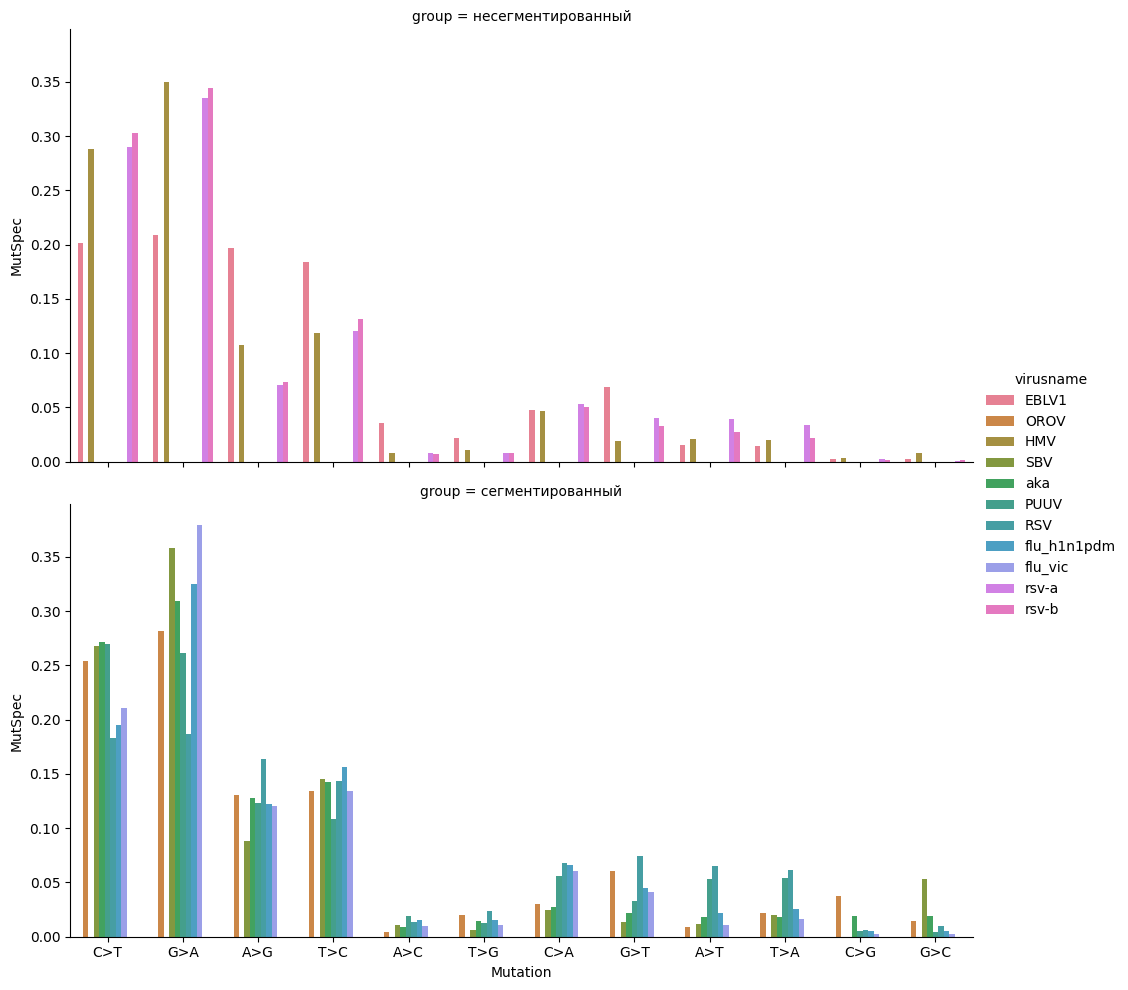

In [66]:
sns.catplot(
    data=_, x='Mutation', y='MutSpec', hue='virusname', row='group',
    # hue_order=['сегментированный', 'несегментированный'],
    kind='bar', aspect=2,
    order=['C>T', 'G>A', 'A>G', 'T>C', 'A>C', 'T>G', 'C>A', 'G>T', 'A>T', 'T>A', 'C>G', 'G>C'],

)

In [26]:
# calc eq freqs of mean spectra
from utils import get_equilibrium_freqs

data = []
gr_mean_ms = df_long.groupby(['group','Mutation']).MutSpec.mean()
for g in gr_mean_ms.index.get_level_values('group').unique():
    ms = gr_mean_ms.loc[g].reset_index().rename(columns={'Mutation': 'Mut'})
    _, eq_freqs = get_equilibrium_freqs(ms)
    data.append(eq_freqs.assign(group=g))

df_eq = pd.concat(data, ignore_index=True)
df_eq.to_csv('data/mean_gr_eq_freq.csv', index=False)
df_eq

,aa,eq_freq,group
0,Leu,0.122447,+ssRNA (14)
1,Ser,0.107977,+ssRNA (14)
2,Arg,0.081763,+ssRNA (14)
3,Val,0.071469,+ssRNA (14)
4,Pro,0.063813,+ssRNA (14)
...,...,...,...
75,Lys,0.025337,dsDNA (7)
76,Gln,0.025250,dsDNA (7)
77,Glu,0.020068,dsDNA (7)
78,Met,0.015907,dsDNA (7)


### Rev-comp for ssRNA(-) viruses

In [12]:
df_long_ex_neg = df_long.query('group != "-ssRNA (11)"')
df_long_neg = df_long.query('group == "-ssRNA (11)"')
df_long_neg['Mutation'] = df_long_neg['Mutation'].str.translate(str.maketrans('ACGT', 'TGCA'))

df_long_new = pd.concat([df_long_ex_neg, df_long_neg], ignore_index=True)
df_long_neg

,Type,taxname,virusname,Mutation,MutSpec,group
3,-,Influenza A virus,flu_a,T>G,0.008852,-ssRNA (11)
14,-,European bat 1 lyssavirus,EBLV1,T>G,0.035927,-ssRNA (11)
16,-,Oropouche orthobunyavirus,OROV,T>G,0.004384,-ssRNA (11)
20,-,Human metapneumovirus,HMV,T>G,0.008090,-ssRNA (11)
25,-,Schmallenberg orthobunyavirus,SBV,T>G,0.011045,-ssRNA (11)
...,...,...,...,...,...,...
410,-,Schmallenberg orthobunyavirus,SBV,A>C,0.006544,-ssRNA (11)
413,-,Akabane orthobunyavirus,aka,A>C,0.014812,-ssRNA (11)
415,-,Puumala orthohantavirus,PUUV,A>C,0.012302,-ssRNA (11)
416,-,Rice stripe tenuivirus,RSV,A>C,0.023569,-ssRNA (11)


In [20]:
import pingouin as pg

for mut in ['C>T', 'G>A', 'A>G', 'T>C']:
    print(f'Analyzing {mut}...')
    cur_df = df_long_new.query(f'Mutation == "{mut}"')
    if pg.normality(cur_df, dv='MutSpec', group='group').normal.all():
        parametric = True
    else:
        print(f'{mut} is not normal, using non-parametric test')
        parametric = False

    _ = pg.pairwise_tests(data=cur_df,
        dv='MutSpec', between='group', padjust='bonf', parametric=parametric)
    _res = _[['A', 'B', 'p-corr']][(_['p-corr'] < 0.05) & (~_['A'].str.contains('CoV')) & (~_['B'].str.contains('CoV'))]
    if len(_res) > 0:
        print(f'Significant differences for {mut}:')
        print(_res)
    print('---\n')

Analyzing C>T...
---

Analyzing G>A...
Significant differences for G>A:
             A            B   p-corr
1  +ssRNA (14)  -ssRNA (11)  0.00235
---

Analyzing A>G...
---

Analyzing T>C...
Significant differences for T>C:
             A            B    p-corr
1  +ssRNA (14)  -ssRNA (11)  0.005764
---



/tmp/ipykernel_39194/2509657993.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['C>U', 'G>A', 'A>G', 'U>C'], fontsize=16, fontweight='bold')


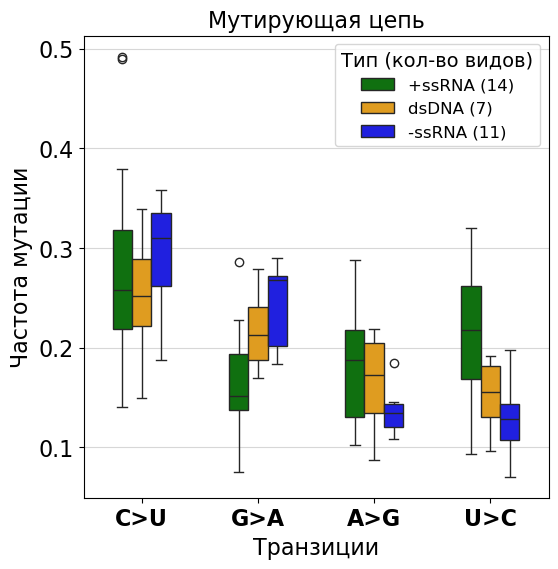

In [17]:
plt.figure(figsize=(6, 6))

sns.set_palette(sns.color_palette(['green', 'orange','blue']))

ax = sns.boxplot(
    data=df_long_new, x='Mutation', y='MutSpec', hue='group', 
    hue_order=[ '+ssRNA (14)', 'dsDNA (7)', '-ssRNA (11)'],
    order=['C>T', 'G>A', 'A>G', 'T>C'],
    width=0.5,
)
plt.title('Мутирующая цепь', fontsize=16)
plt.legend(title='Тип (кол-во видов)', fontsize=12, title_fontsize=14)
plt.yticks(fontsize=16)
plt.xlabel('Транзиции', fontsize=16)
plt.ylabel('Частота мутации', fontsize=16)
ax.set_xticklabels(['C>U', 'G>A', 'A>G', 'U>C'], fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.5)
ax.set_axisbelow(True)

Compare ratios of + to minus

In [33]:
_ = df_long.groupby(['Type', 'Mutation']).MutSpec.mean().unstack()[['C>T', 'G>A', 'A>G', 'T>C']]
(_.loc['+'] / _.loc['-'])

Mutation
C>T    1.234677
G>A    0.532951
A>G    1.187600
T>C    1.320838
dtype: float64

In [34]:
_ = df_long_new.groupby(['Type', 'Mutation']).MutSpec.mean().unstack()[['C>T', 'G>A', 'A>G', 'T>C']]
(_.loc['+'] / _.loc['-'])

Mutation
C>T    1.046243
G>A    0.628938
A>G    1.118370
T>C    1.402600
dtype: float64